
---

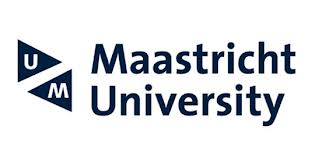

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


Version 2026-2027

---

Welcome to Tutorial 08: BERT and HuggingFace. In this notebook you will learn how to use pretrained BERT models from HuggingFace for various NLP tasks including tokenization, sentiment analysis, named entity recognition, POS tagging, and multilingual NLP.

For this notebook we would need our GPU accelerator. Make sure you have selected the GPU runtime in Google Colab (Runtime > Change Runtime Type > T4 GPU).

## Learning Goals

After completing this tutorial, you will be able to:

- **Use** the HuggingFace `transformers` library to load pretrained BERT models and tokenizers.
- **Understand** BERT's vocabulary and WordPiece tokenization, including how out-of-vocabulary words are handled.
- **Fine-tune** BERT for sequence classification tasks (e.g., sentiment analysis on IMDB).
- **Fine-tune** BERT for token classification tasks (e.g., Named Entity Recognition on CoNLL-2003).
- **Evaluate** fine-tuned models using precision, recall, F1-score, and accuracy metrics.
- **Explain** the differences between mBERT and XLM-R for multilingual NLP and cross-lingual transfer.

#BERT and HuggingFace

So far, we have worked with a various amount of BERT models. BERT has a lot to offer:

a) pretrained models

b) bi-directional word embeddings

c) ability to deal with out-of vacabulairy words using sub-words (including byte pair enciding, byte-level byte pairing and the WordPiece tokenizer)

d) mask language modeling

e) next sentence prediction

Remember, there are 1000's of different BERT models, varying in size (different number of encoding layers L, different number of attention heads A, different number of hidden units H), and with different pre-training data.  

In this tutorial we will repeat the steps to load the tokenizers and basic embeddings. After that, we will take it a step further.



Hugging Face is an organization that is behind the very popular open-source library `transformers`. It is very useful and powerful for several NLP and NLU tasks. Transformers models work well when already pretrained, and the `transformers` library includes thousands of pre-trained models in about 100+ natural languages. Its ease of use and extendability is also a plus. You can run state-of-the-art models with just a few lines of code.

We can install `transformers` (and the `datasets` library) directly using pip as shown in the following:


In [ ]:
import importlib, subprocess, sys
to_install = [p for p, m in [('transformers[torch]', 'transformers'), ('datasets', 'datasets')]
              if importlib.util.find_spec(m) is None]
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])


Lets make sure we get the same results every time we run the same code in the notebook (reproducability). We can do this by setting the seeds of the packages we use. Like this:

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

## Vocabulary and Tokenizers

We can tokenize a piece of text by importing the tokenizer from the `transformers` library. Then to tokenize we use the `tokenize()` function. This function splits the texts based on the items in the vocabulary.

In [ ]:
from transformers import BertTokenizer, BertModel
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

BERT also has extra tokens involved, for example:

1. The classification token `[CLS]`. This token is for classification of the transformer. We attend to this token and we can take an embedding representation of a whole sentence by just using this token.
2. The separation token `[SEP]`. This token is to let the model know we have separate sentences within a full text we pass to the model.

In [ ]:
text = "Here is the sentence I want embeddings for."
marked_text = "[CLS] " + text + " [SEP]"

# Tokenize our sentence with the BERT tokenizer.
tokenized_text = tokenizer.tokenize(marked_text)

# Print out the tokens.
tokenized_text

This text is not yet something we can pass through our model yet. For that, we need it converted to integers (ids). We can do this with the `convert_tokens_to_ids` function:

In [ ]:
tokenizer.convert_tokens_to_ids(tokenized_text)

This function just looks up the tokens in the vocabulary. For example, the id 5000 means `knight`, because it is the 5000th index in the vocabulary:

In [ ]:
list(tokenizer.vocab.keys())[5000:5020]

We can convert ids back to tokens with the `convert_ids_to_tokens` function:

In [ ]:
ids = tokenizer.convert_tokens_to_ids(tokenized_text)
tokenizer.convert_ids_to_tokens(ids)

Normally, we would just use `encode` or `encode_plus`. `encode` adds the `CLS` and `SEP`, add the `convert_tokens_to_ids` and `tokenize` steps into one step. `encode_plus` does this and also appends a `attention_mask` and `token_type_ids`.

In [ ]:
tokenizer.encode(text)

## BERT Models
In this section, we will learn how to extract embeddings from the pre-trained BERT. Consider the sentence 'I love Maastricht'. Let's see how to obtain the contextualized word embedding of all the words in the sentence using the pre-trained BERT model with Hugging Face's transformer library.

Lets consider the `HuggingFace` library. We can check all the available pre-trained models [here](https://huggingface.co/models). For BERT, these models we can filter down on the `bert` [tag](https://huggingface.co/models?other=bert). For now, we use the [bert-base-uncased](https://huggingface.co/bert-base-uncased) model. As the name suggests, it a BERT with 12 encoders and it is trained with uncased tokens. The representation size will be 768. The `uncased` means that we have only lowercase letters in our tokenizer.

We can download and load the pretrained model like this. Lets look how the model is implemented. Can you notice the 12 layers/encoders of the model? Also notice the different type of inputs we have in the embedding layer. The word embedding, that converts the token ids we have (30522 of them) into 768. Same holds for the position embeddings and the token_type_embeddings we could put in.

In [ ]:
model = BertModel.from_pretrained('bert-base-uncased')
model

# Finetuning BERT for sentiment analysis

Let's learn how to finetune the pre-trained BERT for text classification tasks. Say, we are performing sentiment analysis. In the sentiment analysis, our goal is to classify whether a sentence is positive or negative. Suppose, we have a dataset containing sentences along with their labels.

Consider a sentence: `I love AI`. First, we tokenize the sentence, add the `[CLS]` token at the beginning, and `[SEP]` token at the end of the sentence. Then, we feed the tokens as an input to the pre-trained BERT and get the embeddings of all the tokens.

Next, we ignore the embedding of all other tokens and take only the embedding of `[CLS]` token which is $R_{[CLS]}$. The embedding of the `[CLS]` token will hold the aggregate representation of the sentence. We feed $R_{[CLS]}$ to a classifier (feed-forward network with softmax function) and train the classifier to perform sentiment analysis.

Wait! How does it differ from what we saw in the tutorial on Word Embeddings. How finetuning the pre-trained BERT differs from using the pre-trained BERT as a feature extractor?

In the first section, we learned that after extracting the embedding $R_{[CLS]}$ of a sentence, we feed the $R_{[CLS]}$ to a classifier and train the classifier to perform classification. Similarly, during finetuning, we feed the embedding of $R_{[CLS]}$ to a classifier and train the classifier to perform classification.

The difference is that when we finetune the pre-trained BERT, we can update the weights of the pre-trained BERT along with a classifier. But when we use the pre-trained BERT as a feature extractor, we can update only the weights of a classifier and not the pre-trained BERT.

During finetuning, we can adjust the weights of the model in the following two ways:

- Update the weights of the pre-trained BERT along with the classification layer
- Update only the weights of the classification layer and not the pre-trained BERT. When we do this, it becomes the same as using the pre-trained BERT as a feature extractor

The following figure shows how we finetune the pre-trained BERT for the sentiment analysis task:


As we can observe from the preceding figure, we feed the tokens to the pre-trained BERT and get the embedding of all the tokens. We take the embedding of `[CLS]` token and feed it to a feedforward network with a softmax function and perform classification.

Let's get a better understanding of how finetuning works by getting hands-on with finetuning the pre-trained BERT for sentiment analysis in the next section.



Import the necessary modules:

In [ ]:
from transformers import BertForSequenceClassification, BertTokenizerFast, Trainer, TrainingArguments
import torch
import numpy as np


Load the model and dataset. First, let's download and load the dataset using the `datasets` library. We only take the first 20 percent from the training set and the first 5 percent from the test set, otherwise the training will take too long.

In [ ]:
from datasets import load_dataset
train_set = load_dataset("imdb", split="train[:25%]")
test_set = load_dataset("imdb", split="test[:10%]")

You can also use this one for a better balanced split of the samples from the data set over positive and negative data points (Unfortunately, there is no method to randomize the split argument in the load_dataset function):

In [ ]:
from datasets import load_dataset
train_set = load_dataset("imdb", split="train[:12%]+train[-13%:]")
test_set = load_dataset("imdb", split="test[:5%]+test[-5%:]")



Let's print the dataset:

In [ ]:
# train_set
print(train_set)

And the test set:

In [ ]:
test_set


Next, let's download and load the pre-trained BERT model. In this example, we use the pre-trained bert-base-uncased model. As we can observe below, since we are performing sequence classification, we use the BertForSequenceClassification class:


In [ ]:
model = BertForSequenceClassification.from_pretrained('bert-base-uncased')


Next, we download and load the tokenizer which is used for pretraining the bert-base-uncased model.
As we can observe, we create the tokenizer using the BertTokenizerFastclass instead of BertTokenizer. The BertTokenizerFast class has many advantages compared to BertTokenizer. We will learn about this in the next section:


In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')


Now that we loaded the dataset and model, next let's preprocess the dataset.

## Preprocess the dataset
We can preprocess the dataset in a quicker way using our tokenizer. For example, consider the sentence: 'I love AI'.  

First, we tokenize the sentence and add the `[CLS]` token at the beginning and `[SEP]` token at the end as shown below:


```
tokens = [ [CLS], I, love, AI, [SEP] ]
```


Next, we map the tokens to the unique input ids (token ids). Suppose the following are the unique input ids (token ids):


```
input_ids = [101, 1045, 2293, 3000, 102]
```

Then, we need to add the segment ids (token type ids). Wait, what are segment ids? Suppose we have two sentences in the input. In that case, segment ids are used to distinguish one sentence from the other. All the tokens from the first sentence will be mapped to 0 and all the tokens from the second sentence will be mapped to 1. Since here we have only one sentence, all the tokens will be mapped to 0 as shown below:


```
token_type_ids = [0, 0, 0, 0, 0]
```


Now, we need to create the attention mask. We know that an attention mask is used to differentiate the actual tokens and `[PAD]` tokens. It will map all the actual tokens to 1 and the `[PAD]` tokens to 0. Suppose, our tokens length should be 5. Now, our tokens list has already 5 tokens. So, we don't have to add `[PAD]` token. Then our attention mask will become:


```
attention_mask = [1, 1, 1, 1, 1]
```


That's it. But instead of doing all the above steps manually, our tokenizer will do these steps for us. We just need to pass the sentence to the tokenizer as shown below:


In [ ]:
tokenizer('I love AI')


With the tokenizer, we can also pass any number of sentences and perform padding dynamically. To do that, we need to set padding to True and also the maximum sequence length. For instance, as shown below, we pass three sentences and we set the maximum sequence length, max_length to 5:


In [ ]:
tokenizer(['I love AI', 'birds fly','snow fall'], padding = True, max_length=5)


That's it, with the tokenizer, we can easily preprocess our dataset. So we define a function called preprocess for processing the dataset as shown below:


In [ ]:
def preprocess(data):
    return tokenizer(data['text'], padding=True, truncation=True)


Now, we preprocess the train and test set using the preprocess function. The dataset loader still shows 0/1 when its done, its a known [bug](https://github.com/huggingface/datasets/issues/5117) in the library. Your dataset is still preprocessed.

In [ ]:
train_set = train_set.map(preprocess, batched=True, batch_size=len(train_set))
test_set = test_set.map(preprocess, batched=True, batch_size=len(train_set))

In [ ]:
train_set[0].keys()

That's it. Now that we have the dataset ready, let's train the model.

## Training the model


Define the batch size and epoch size.

Batch size is how many items we put in per loop. So a batch size of 8 means 8 items per rendering. We need to do this because of the memory allocation of the GPU, its impossible to do the whole dataset at once, because this otherwise wouldn't fit in the GPU.

The number of epochs is how many times we loop over the whole dataset.

In [ ]:
batch_size = 8
epochs = 1


Define the warmup steps and weight decay.

Warmup steps means that in the beginning of training we set the learning to a really slow amount (slow learning rate). We let our network components kind of get used to our dataset, before we really move a lot in our optimization.

We use weight decay to avoid overfitting by adding a penalty to our training function.



In [ ]:
warmup_steps = 500
weight_decay = 0.01

Lets first define what metrics we want to compute. We deal with binary classification, so it makes sense to include precision, recall, f1 and accuracy.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

This is how you would define your training loop in the `transformers` library: We can put things in like the number of training epochs, batch size, warmup steps and weight decay. Now lets define the training arguments:

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    warmup_steps=warmup_steps,
    weight_decay=weight_decay,
    logging_dir='./logs',
)



Now define the trainer:

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_set,
    eval_dataset=test_set
)

Start training the model. The training takes about 10 minutes in total!

Please make sure you are on GPU, otherwise this takes even longer.

In [ ]:
import wandb
wandb.init(mode="disabled")
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)
trainer.train()

In [ ]:
trainer.evaluate()


After training we can evaluate the model using the evaluate function:

# Fine-tuning Pretrained Transformers for Named Entity Recognition (NER)

In the previous section we worked on sentiment prediction with just two classes using BERT. In this notebook we'll be using BERT-based models for Named Entity Recognition. Again, exactly the same model, but now we train it for a different dataset. Lets see if we can tag some sentences.

One thing to notice is that we now have a different class type within Bert that we going to use. Notice that instead of BertForSequenceClassification we now use BertForTokenClassification. The former we use for predicting labels from a whole piece of text (e.g. sentences). Now we want to classify per token basis.

We should reimport the model first, otherwise it is still finetuned on the previous task. That knowledge does not make sense anymore for this task.

In [ ]:
from transformers import BertForTokenClassification, AutoTokenizer
model = BertForTokenClassification.from_pretrained('bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

## Preparing the data
Now let's also import a new dataset. This time we are going to work on a PoS dataset. We will be using CoNLL. This dataset contains news stories from Reuters, and contains 3 tasks: part of speech tagging (POS), named entity recognition (NER) and chunking. We import it with the `dataset` library.

In [ ]:
from datasets import load_dataset

# 1) Kleine, data-only mirror van CoNLL-2003 in Parquet:
ds = load_dataset("hgissbkh/conll2003-en")  # bevat train/validation/test
print(ds)



Lets visualise the structure:

In [ ]:
example = ds["train"][0]
print(example)

dataset = ds


This is how a token looks like:

In [ ]:
dataset["train"][0]["words"]

This is how a named entity recognition tag looks like:

In [ ]:
dataset["train"][0]["ner"]

These named entity recognition tags are integers that can be converted with a function back to ones that do have meaning. Let's try it:

In [ ]:
ner_features = dataset["train"].features["ner"].feature.names
print(ner_features)

So converting above pos tags means we just have to do this:

In [ ]:
words = dataset["train"][0]["words"]
labels = dataset["train"][0]["ner"]
line1 = ""
line2 = ""
for word, label in zip(words, labels):
    full_label = ner_features[label]
    max_length = max(len(word), len(full_label))
    line1 += word + " " * (max_length - len(word) + 1)
    line2 += full_label + " " * (max_length - len(full_label) + 1)

print(line1)
print(line2)

Now lets use our tokenizer. We need whole words to perform classification. As we know, a transformers tokenizer splits its content into subwords or bytes. We can solve this with using `tokenizer` as usual and just add `is_split_into_words=True`. For example:


In [ ]:
inputs = tokenizer(dataset["train"][0]["words"], is_split_into_words=True)
inputs.tokens()

However, we immediately see a problem. As we can see, the tokenizer added the special tokens used by the model (`[CLS]` at the beginning and `[SEP]` at the end) and left most of the words untouched. The word lamb, however, was tokenized into two subwords, la and ##mb. This introduces a mismatch between our inputs and the labels: the list of labels has only 9 elements, whereas our input now has 11 tokens. Accounting for the special tokens is easy (we know they are at the beginning and the end), but we also need to make sure we align all the labels with the proper words.



In [ ]:
inputs = tokenizer(dataset["train"][0]["words"], is_split_into_words=True)
inputs.word_ids()

For the labels, we have the problem that the `CLS` token and `SEP` token are not really pos tags, and since the word ids are splitted up, we need to create a function that can map parts of words to tokens. We remove the two tokens and parts of subwords by changing them in the align function to `-100`:

In [ ]:
def align_labels_with_tokens(labels, word_ids):
    new_labels = []
    current_word = None
    for word_id in word_ids:
        if word_id != current_word:
            current_word = word_id
            label = -100 if word_id is None else labels[word_id]
            new_labels.append(label)
        else:
            new_labels.append(-100)

    return new_labels

In [ ]:
labels = dataset["train"][0]["ner"]
word_ids = inputs.word_ids()
print(labels)
print(align_labels_with_tokens(labels, word_ids))

To preprocess our whole dataset, we need to tokenize all the inputs and apply `align_labels_with_tokens()` on all the labels. To take advantage of the speed of our fast tokenizer, it’s best to tokenize lots of texts at the same time, so we’ll write a function that processes a list of examples and use the `Dataset.map()` method with the option `batched=True`. The only thing that is different from our previous example is that the `word_ids()` function needs to get the index of the example we want the word IDs of when the inputs to the tokenizer are lists of texts (or in our case, list of lists of words), so we add that too:

In [ ]:
def align_labels(examples):
    tokenized_inputs = tokenizer(examples["words"], truncation=True, is_split_into_words=True)
    new_labels = []
    for i, labels in enumerate(examples["ner"]):
        word_ids = tokenized_inputs.word_ids(i)
        new_labels.append(align_labels_with_tokens(labels, word_ids))
    tokenized_inputs["labels"] = new_labels
    return tokenized_inputs

Note that we haven’t padded our inputs yet; we’ll do that later, when creating the batches with a data collator.

We can now apply all that preprocessing in one go on the other splits of our dataset:

Please note that the loading function does not fully load to 100%, and the loading bar shows a red color! This is due to a bug in the [datasets](https://github.com/huggingface/datasets/issues/5117) library.

In [ ]:
tokenized_datasets = dataset.map(align_labels, batched=True, remove_columns=dataset["train"].column_names)

## Fine-tuning the model:

The actual code using the Trainer will be the same as before; the only changes are the way the data is collated into a batch and the metric computation function.

With the data collator, our labels should be padded the exact same way as the inputs so that they stay the same size, using -100 as a value so that the corresponding predictions are ignored in the loss computation.

In [ ]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
batch = data_collator([tokenized_datasets["train"][i] for i in range(2)])
print("Padded:")
print(batch["labels"])
print("Not padded:")
for i in range(2):
    print(tokenized_datasets["train"][i]["labels"])

To have the `Trainer` compute a metric every epoch, we will need to define a `compute_metrics()` function that takes the arrays of predictions and labels, and returns a dictionary with the metric names and values.

The traditional framework used to evaluate token classification prediction is [seqeval](https://github.com/chakki-works/seqeval). To use this metric, we first need to install the *seqeval* and the *evaluate* libraries and then load it in:

In [ ]:
import importlib, subprocess, sys
to_install = [p for p, m in [('seqeval', 'seqeval'), ('evaluate', 'evaluate')]
              if importlib.util.find_spec(m) is None]
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])
import evaluate
metric = evaluate.load("seqeval")


This metric does not behave like the standard accuracy: it will actually take the lists of labels as strings, not integers, so we will need to fully decode the predictions and labels before passing them to the metric. Let’s see how it works. First, we’ll get the labels for our first training example:

In [ ]:
labels = dataset["train"][0]["ner"]
labels = [ner_features[i] for i in labels]
predictions = labels.copy()
predictions[2] = "O"
metric.compute(predictions=[predictions], references=[labels])

Lets now define a `compute_metrics()` function:

In [ ]:
def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    # Remove ignored index (special tokens) and convert to labels
    true_labels = [[ner_features[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [ner_features[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    all_metrics = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": all_metrics["overall_precision"],
        "recall": all_metrics["overall_recall"],
        "f1": all_metrics["overall_f1"],
        "accuracy": all_metrics["overall_accuracy"],
    }

Since we are working on a token classification problem, we will use the `AutoModelForTokenClassification` class. The main thing to remember when defining this model is to pass along some information on the number of labels we have. The easiest way to do this is to pass that number with the num_labels argument, but if we want a nice inference widget working like the one we saw at the beginning of this section, it’s better to set the correct label correspondences instead.

They should be set by two dictionaries, `id2label` and `label2id`, which contain the mappings from ID to label and vice versa:

In [ ]:
from transformers import AutoModelForTokenClassification
id2label = {i: label for i, label in enumerate(ner_features)}
label2id = {v: k for k, v in id2label.items()}
model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    id2label=id2label,
    label2id=label2id,
)

Lets run the model! Make sure you are on your GPU, otherwise it will take ages again.

In [ ]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)
trainer.train()


In [ ]:
trainer.evaluate()

## Other Examples of Fine-tuning BERT

In this tutorial we fine-tuned BERT for sentiment classification, Named Entity Recognition, and POS tagging. However, BERT can be fine-tuned for many other downstream tasks. The pattern is always the same:

1. Load a pretrained BERT model
2. Add a task-specific head (sequence, token, or span prediction)
3. Fine-tune on labeled data

| Task | Type | Example |
|------|------|---------|
| **Extractive QA** | Span prediction | Given a passage + question, locate the answer span (e.g., SQuAD) |
| **Semantic Textual Similarity** | Sentence-pair regression | Determine how similar two sentences are |
| **Natural Language Inference** | Sentence-pair classification | Entailment, contradiction, or neutral |
| **Intent Classification** | Sequence classification | Detect user intent in chatbot queries |
| **Multi-label Classification** | Multi-label sequence classification | Assign multiple categories to a document |
| **Extractive Summarization** | Per-sentence classification | Select the most informative sentences from a document |

> For a deeper discussion of fine-tuning techniques (including LoRA, adapters, and efficient methods), see **Tutorial 11**.

#BERT and other Languages

## Multilingual BERT (m-BERT)

BERT is trained on English text only. **Multilingual BERT (m-BERT)** extends this to 104 languages by training on their Wikipedia texts with masked language modeling and next sentence prediction.

Key properties of m-BERT:
- Uses **110K shared WordPiece vocabulary** across all 104 languages
- **Under-samples** high-resource languages and **over-samples** low-resource languages to avoid overfitting
- Learns cross-lingual representations **without** any explicit cross-lingual training objective
- Available in two variants: `bert-base-multilingual-cased` and `bert-base-multilingual-uncased` (both 12 layers, 12 heads, 768 hidden, 110M parameters)

m-BERT is compatible with the HuggingFace `transformers` library and can be used as a drop-in replacement for BERT.

First, let's import the necessary modules:

In [ ]:
from transformers import BertTokenizer, BertLMHeadModel


Download and load the pre-trained M-BERT model and the tokenizer:

In [ ]:
mbert = BertLMHeadModel.from_pretrained('bert-base-multilingual-cased')
mbert_tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

Lets try a french sentence on a masked language modelling perspective. This is the task that BERT originally was trained on. Specific words in the sentence were masked, and the goal for the model was to predict them.

Lets put the sentence through a tokenizer first:

In [ ]:
inputs = mbert_tokenizer("[MASK] est la capitale de la France", return_tensors="pt")

Feed the tokens to the model, get the logits out of it and decode the sentence:

In [ ]:
logits = mbert(**inputs).logits
mbert_tokenizer.decode(logits[0].argmax(axis=-1))

It manages to predict words correctly even in other languages!

##XLM-BERT

XLM was released by Facebook as an answer on `BERT` and `M-BERT`. In XLM, they subsample the outputs. XLM uses streams of text, uses byte-pair encoding instead of sentencepiece encoding. Moreover, M-BERT is trained using a masked langauge model objective, where XLM also has a new modeling technique named Translation Language Modeling. It masks tokens out and tries to guess the translation of that specific token.

We first need to install an extra library:

In [ ]:
import importlib, subprocess, sys
if importlib.util.find_spec('sacremoses') is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sacremoses"])


Now we can use the `transformers` implementation like this:

In [ ]:
from transformers import XLMTokenizer, XLMWithLMHeadModel
import torch

xlm_tokenizer = XLMTokenizer.from_pretrained("xlm-mlm-100-1280")
xlm_model = XLMWithLMHeadModel.from_pretrained("xlm-mlm-100-1280")

Lets try the same task as with M-BERT again! This time instead of the token `[MASK]` we need to put in the token `<special1>`.

In [ ]:
inputs = xlm_tokenizer("<special1> est la capitale de la France", return_tensors="pt")
logits = xlm_model(**inputs).logits
xlm_tokenizer.decode(logits[0].argmax(axis=-1))

## Take Away

### Key Concepts

| Concept | Description |
|---|---|
| **BERT** | Bidirectional Encoder Representations from Transformers — pretrained on masked language modeling (MLM) and next sentence prediction (NSP). Produces contextualized word embeddings. |
| **HuggingFace Transformers** | Open-source library providing pretrained models, tokenizers, and training utilities. Key classes: `AutoTokenizer`, `AutoModel`, `Trainer`, `TrainingArguments`. |
| **WordPiece Tokenization** | BERT's subword tokenization splits unknown words into known subwords (prefixed with `##`). Handles OOV words while keeping vocabulary size manageable (~30K tokens). |
| **Fine-tuning** | Adapting a pretrained model to a downstream task by adding a task-specific head and training on labeled data. Much less data needed than training from scratch. |
| **Sequence Classification** | Adding a linear classification head on top of the [CLS] token for tasks like sentiment analysis. Uses `BertForSequenceClassification`. |
| **Token Classification** | Adding a linear classification head on each token for tasks like NER and POS tagging. Uses `BertForTokenClassification`. |
| **Multilingual BERT (mBERT)** | BERT trained on 104 languages simultaneously. Shares vocabulary and model parameters across languages, enabling cross-lingual transfer. |
| **XLM / XLM-R** | Multilingual models by Facebook. XLM-R (XLM-RoBERTa) generally outperforms mBERT on cross-lingual benchmarks due to more training data and improved training procedure. |

### Fine-tuning Pipeline

1. **Load** pretrained model and tokenizer from HuggingFace
2. **Prepare** dataset using `datasets` library and tokenize with padding/truncation
3. **Configure** training with `TrainingArguments` (epochs, batch size, learning rate, etc.)
4. **Train** using `Trainer` class with appropriate metrics
5. **Evaluate** on validation/test set using task-specific metrics (accuracy, F1, precision, recall)

# Exercises

## Exercise A1: BERT Tokenization and Embeddings (10 points)

**a)** (5 points - code) Using the BERT tokenizer from the tutorial, tokenize at least 5 different sentences that contain:
- A common word (e.g., "running")
- An uncommon/rare word (e.g., "pneumonoultramicroscopicsilicovolcanoconiosis")
- A misspelled word (e.g., "definately")
- A technical term (e.g., "backpropagation")
- A word from another language (e.g., "Kindergarten")

For each sentence, display the tokens and their IDs. Highlight which words get split into subwords (with `##` prefix).

**b)** (5 points - explanation) Based on your observations:
- How does WordPiece tokenization handle unknown or rare words?
- What are the advantages and disadvantages of subword tokenization compared to word-level and character-level tokenization?
- Why is a vocabulary size of ~30K a good trade-off?

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A1 (5 points)
assert isinstance(tokenization_results, list), "tokenization_results must be a list"
assert len(tokenization_results) >= 5, "Must test at least 5 sentences"
assert all("tokens" in r for r in tokenization_results), "Each result must contain tokens"
assert all("ids" in r for r in tokenization_results), "Each result must contain IDs"
assert any(r["num_subwords"] > 0 for r in tokenization_results), "At least one sentence should have subword tokens"
print("All A1 code tests passed!")

**b) Write your explanation below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A2: Sentiment Analysis with BERT (10 points)

The sentiment classifier has been fine-tuned in the tutorial above. Use it to analyze new texts.

**a)** (5 points - code) The pipeline setup is provided below. Add at least 5 new test sentences (not from IMDB) covering: clearly positive, clearly negative, ambiguous/neutral, sarcasm, and a longer review. Run the pipeline and inspect the results.

**b)** (5 points - explanation) Analyze the model's predictions: Where does it succeed/fail? How do confidence scores relate to accuracy? What are the main limitations of a binary sentiment classifier trained on movie reviews?

In [ ]:
# Pipeline setup (provided)
from transformers import pipeline

sentiment_pipeline = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A2 (5 points)
assert isinstance(prediction_results, list), "prediction_results must be a list"
assert len(prediction_results) >= 5, "Must test at least 5 sentences"
assert all("label" in r for r in prediction_results), "Each result must have a label"
assert all("score" in r for r in prediction_results), "Each result must have a score"
assert all(0 <= r["score"] <= 1 for r in prediction_results), "Scores must be between 0 and 1"
print("All A2 code tests passed!")

**b) Write your analysis below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A3: POS Tagging with BERT (15 points)

The tutorial showed how to fine-tune BERT for NER. Now apply the same approach to **POS tagging**.

**a)** (10 points - code) The scaffold below loads the dataset, model, and sets up the training pipeline — following the same pattern as the NER example in the tutorial. Fill in the `TODO` sections to:
1. Build the label mappings (`id2label`, `label2id`)
2. Complete the `tokenize_and_align` function to handle subword label alignment (same technique as the tutorial's NER alignment)
3. Run training and evaluation

**b)** (5 points - explanation) Compare the POS tagger's F1 score with the NER model from the tutorial. Which task is easier and why? How does subword tokenization affect token classification?

In [ ]:
# POS fine-tuning scaffold — same pattern as NER in the tutorial
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import transformers
transformers.logging.set_verbosity_error()
from datasets import disable_progress_bar
disable_progress_bar()

from datasets import load_dataset
from transformers import (
    BertForTokenClassification, AutoTokenizer,
    TrainingArguments, Trainer, DataCollatorForTokenClassification
)
import numpy as np

# Load dataset
dataset = load_dataset("universal_dependencies", "en_ewt", trust_remote_code=True)
pos_tags = dataset["train"].features["upos"].feature.names
num_labels = len(pos_tags)
print(f"POS tags ({num_labels}): {pos_tags}")

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A3 (10 points)
assert 'pos_eval_results' in dir(), "pos_eval_results must exist"
assert isinstance(pos_eval_results, dict), "pos_eval_results must be a dictionary"
# Check that metrics are present and reasonable
eval_f1 = pos_eval_results.get("eval_f1", pos_eval_results.get("f1", 0))
assert eval_f1 > 0.5, f"F1 should be > 0.5, got {eval_f1:.4f}"
print(f"POS Tagger F1: {eval_f1:.4f}")
print("All A3 code tests passed!")

**b) Write your comparison below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Exercise A4: Multilingual BERT Models (10 points)

**a)** (5 points - code) The scaffold below loads mBERT and XLM-R for masked language modeling. Add sentences in at least **3 languages** (including English) with a `[MASK]` token, run both models, and compare their predictions.

**b)** (5 points - explanation) Which model performs better? What are the key architectural and training differences between mBERT and XLM-R that explain the performance gap?

In [ ]:
# Model setup (provided)
from transformers import pipeline
import pandas as pd

MODEL_IDS = {
    "mBERT": "bert-base-multilingual-cased",
    "XLM-R": "xlm-roberta-base"
}

### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

In [ ]:
# Tests for A4 (5 points)
assert isinstance(mlm_results, list), "mlm_results must be a list"
assert len(mlm_results) >= 6, "Must have results for at least 3 languages × 2 models"
assert any(r["model"] == "mBERT" for r in mlm_results), "Must include mBERT results"
assert any(r["model"] == "XLM-R" for r in mlm_results), "Must include XLM-R results"
languages_tested = set(r["language"] for r in mlm_results)
assert len(languages_tested) >= 3, f"Must test at least 3 languages, got {len(languages_tested)}"
print(f"Tested {len(languages_tested)} languages with 2 models")
print("All A4 code tests passed!")

**b) Write your comparison below:**

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## References

- Devlin, J. et al. "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding." NAACL 2019. https://arxiv.org/abs/1810.04805
- Conneau, A. et al. "Unsupervised Cross-lingual Representation Learning at Scale." ACL 2020 (XLM-R). https://arxiv.org/abs/1911.02116
- Wolf, T. et al. "HuggingFace's Transformers: State-of-the-art Natural Language Processing." EMNLP 2020. https://github.com/huggingface/transformers
- Ravichandiran, S. "Getting Started with Google BERT." Packt, 2021.
- Sang, E.F.T.K. & De Meulder, F. "Introduction to the CoNLL-2003 Shared Task: Language-Independent Named Entity Recognition." CoNLL 2003.
- Nivre, J. et al. "Universal Dependencies." https://universaldependencies.org/